# Multiple Change Points Detection with Bayesian Inference

## 🎯 Learning Objectives

In the previous notebook, we detected a **single change point**. Real-world time series often have **multiple regime shifts**. This notebook extends the model to detect:

- **2 change points** (3 regimes): Low → Medium → High
- **3 change points** (4 regimes): Low → Medium → High → Medium

### What You'll Learn

1. **Model complexity**: How adding change points affects inference
2. **Identifiability**: Can the model distinguish between multiple change points?
3. **Computational cost**: How MCMC sampling time increases
4. **Interpretation**: Understanding multiple regime shifts

### Key Differences from Single Change Point

| Aspect | Single CP | Multiple CPs |
|--------|-----------|-------------|
| **Parameters** | τ, μ₁, μ₂, σ | τ₁, τ₂, ..., μ₁, μ₂, ..., σ |
| **Complexity** | Simple | More complex |
| **Sampling time** | Fast (~1-2 min) | Slower (~3-5 min) |
| **Identifiability** | Easy | Can be challenging |
| **Interpretation** | One shift | Multiple shifts |

---
## 📦 Setup & Imports

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
import pytensor.tensor as pt

from src.demo_data import (
    generate_synthetic_prices_multiple,
    generate_events_multiple,
    save_data_multiple
)
from src.plots import (
    plot_price_with_multiple_changepoints,
    plot_price_with_events_multiple,
    plot_posterior_tau_multiple,
    plot_posterior_means_multiple
)

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")

az.style.use("arviz-darkgrid")

PyMC version: 5.27.1
ArviZ version: 0.23.3


---
## 🔢 Choose Number of Change Points

Set `n_changepoints` to 2 or 3 to see different scenarios.

In [2]:
n_changepoints = 2

print(f"\n{'='*60}")
print(f"CONFIGURATION: {n_changepoints} Change Points")
print(f"{'='*60}")

if n_changepoints == 2:
    print("\nScenario: 3 regimes")
    print("  Regime 1: ~$30 (low)")
    print("  Regime 2: ~$50 (medium)")
    print("  Regime 3: ~$70 (high)")
    print("\nChange points at ~day 133 and ~day 266")
elif n_changepoints == 3:
    print("\nScenario: 4 regimes")
    print("  Regime 1: ~$25 (low)")
    print("  Regime 2: ~$45 (medium-low)")
    print("  Regime 3: ~$65 (high)")
    print("  Regime 4: ~$50 (medium - correction)")
    print("\nChange points at ~day 100, ~day 200, and ~day 300")

print(f"{'='*60}\n")


CONFIGURATION: 2 Change Points

Scenario: 3 regimes
  Regime 1: ~$30 (low)
  Regime 2: ~$50 (medium)
  Regime 3: ~$70 (high)

Change points at ~day 133 and ~day 266



---
## 📊 Step 1: Generate Synthetic Data with Multiple Change Points

In [3]:
prices_df, events_df, tau_true_list = save_data_multiple(
    output_dir='../data',
    n_changepoints=n_changepoints
)

print("\nFirst few rows:")
print(prices_df.head(10))

print("\nRegime distribution:")
print(prices_df['regime'].value_counts().sort_index())

print("\nEvents:")
print(events_df)

✓ Generated 400 days of price data with 2 change points
✓ Change point 1 at day 132 (2023-05-13)
✓ Change point 2 at day 264 (2023-09-22)
✓ Generated 4 events
✓ Saved to ../data/

First few rows:
        date      price  regime
0 2023-01-01  31.738500       0
1 2023-01-02  29.516075       0
2 2023-01-03  32.266910       0
3 2023-01-04  35.330604       0
4 2023-01-05  29.180463       0
5 2023-01-06  29.180521       0
6 2023-01-07  35.527245       0
7 2023-01-08  32.686022       0
8 2023-01-09  28.356840       0
9 2023-01-10  31.898960       0

Regime distribution:
regime
0    132
1    132
2    136
Name: count, dtype: int64

Events:
                 event_name start_date   end_date      category
0   Major Supply Disruption 2023-05-05 2023-05-21  supply_shock
1       Geopolitical Crisis 2023-09-14 2023-09-30  geopolitical
2   Early Market Adjustment 2023-01-25 2023-01-30        market
3  Late Policy Announcement 2023-11-01 2023-11-07        policy


---
## 📈 Step 2: Visualize the Data

### 2.1 Price Series with True Change Points

✓ Saved: ../outputs/multiple_01_true_changepoints_2cp.png


/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/notebooks/../src/plots.py:266: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


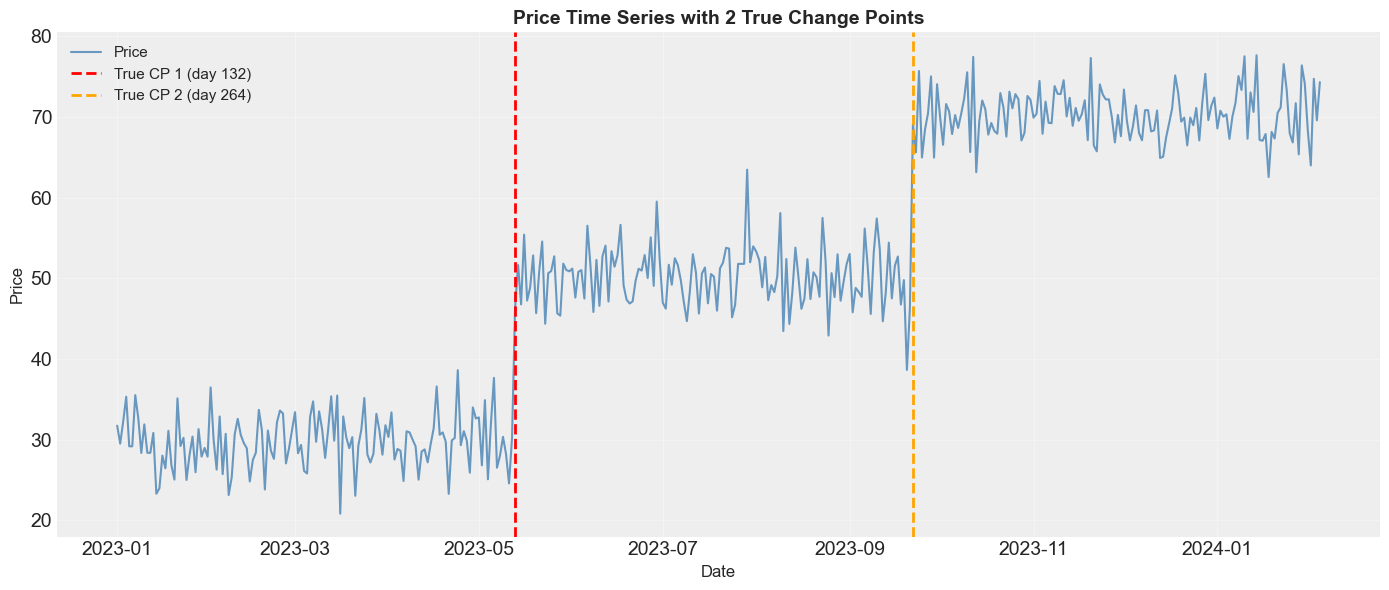

In [4]:
plot_price_with_multiple_changepoints(
    prices_df,
    tau_true_list,
    tau_labels=[f'True CP {i+1}' for i in range(len(tau_true_list))],
    output_path=f'../outputs/multiple_01_true_changepoints_{n_changepoints}cp.png',
    title=f'Price Time Series with {n_changepoints} True Change Points'
)

**Observation**: Notice how the price series has distinct regimes. Each change point marks a transition to a new price level.

### 2.2 Price Series with Events Overlay

/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/notebooks/../src/plots.py:316: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


✓ Saved: ../outputs/multiple_02_events_2cp.png


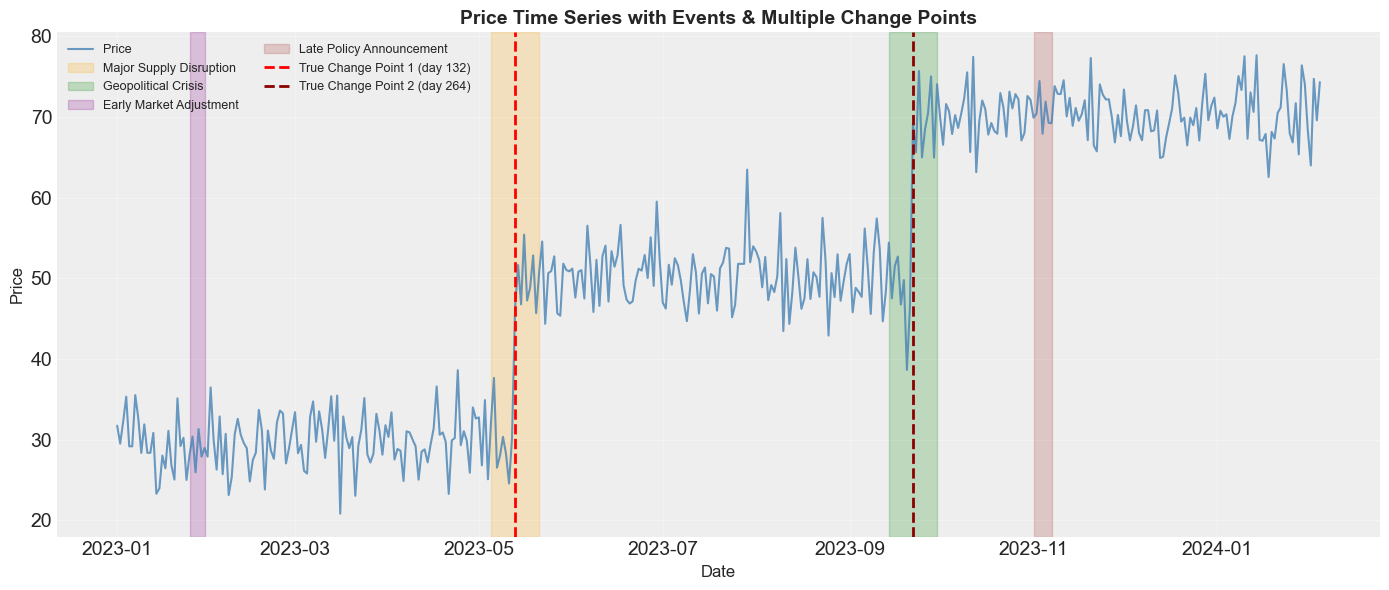

In [5]:
plot_price_with_events_multiple(
    prices_df,
    events_df,
    tau_true_list=tau_true_list,
    output_path=f'../outputs/multiple_02_events_{n_changepoints}cp.png'
)

**Observation**: Events are positioned near each change point, simulating real-world scenarios where external events cause regime shifts.

---
## 🧠 Step 3: Understanding the Multiple Change Point Model

### Model Specification

For **K change points** (K+1 regimes):

#### Priors:
- **τ₁, τ₂, ..., τₖ**: Change point locations
  - Must satisfy: 0 < τ₁ < τ₂ < ... < τₖ < N
  - We use a **sorted uniform** prior
  
- **μ₁, μ₂, ..., μₖ₊₁**: Mean prices for each regime
  - Each ~ Normal(50, 20) (wide prior)
  
- **σ**: Noise level
  - ~ HalfNormal(5)

#### Likelihood:
For each day `i`, determine which regime it belongs to:
- If `i < τ₁`: regime 1, price ~ Normal(μ₁, σ)
- If `τ₁ ≤ i < τ₂`: regime 2, price ~ Normal(μ₂, σ)
- If `τ₂ ≤ i < τ₃`: regime 3, price ~ Normal(μ₃, σ)
- And so on...

### Key Challenge: Ordering Constraint

Change points must be **ordered**: τ₁ < τ₂ < τ₃

We enforce this by:
1. Sampling unconstrained values
2. Sorting them to ensure order
3. This is called a **sorted uniform prior**

---
## 🔧 Step 4: Build the Bayesian Model

In [6]:
n_days = len(prices_df)
prices = prices_df['price'].values
n_regimes = n_changepoints + 1

print(f"Building model with {n_changepoints} change points and {n_regimes} regimes...\n")

with pm.Model() as multiple_changepoint_model:
    
    tau_raw = pm.DiscreteUniform('tau_raw', lower=0, upper=n_days - 1, 
                                  shape=n_changepoints)
    
    tau = pm.Deterministic('tau', pt.sort(tau_raw))
    
    mu = pm.Normal('mu', mu=50, sigma=20, shape=n_regimes)
    
    sigma = pm.HalfNormal('sigma', sigma=5)
    
    idx = np.arange(n_days)
    
    regime = pm.math.sum(
        pm.math.stack([idx >= tau[i] for i in range(n_changepoints)]),
        axis=0
    )
    
    mu_t = mu[regime]
    
    likelihood = pm.Normal('likelihood', mu=mu_t, sigma=sigma, observed=prices)

print("✓ Model built successfully!")
print("\nModel structure:")
print(multiple_changepoint_model)

Building model with 2 change points and 3 regimes...

✓ Model built successfully!

Model structure:


### Understanding the Code

**Key lines explained**:

1. `tau_raw = pm.DiscreteUniform(...)`: Sample K change points independently

2. `tau = pt.sort(tau_raw)`: Sort them to enforce τ₁ < τ₂ < ...

3. `regime = pm.math.sum(...)`: For each day, count how many change points have been passed
   - Before τ₁: regime = 0
   - Between τ₁ and τ₂: regime = 1
   - After τ₂: regime = 2
   - etc.

4. `mu_t = mu[regime]`: Select the appropriate mean for each day's regime

---
## 🎲 Step 5: Run MCMC Sampling

**Warning**: This will take longer than the single change point model!
- 2 change points: ~3-4 minutes
- 3 change points: ~5-7 minutes

We use more tuning steps to ensure convergence.

In [7]:
print("Starting MCMC sampling...")
print("This may take several minutes. Please be patient.\n")

with multiple_changepoint_model:
    trace = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.95,
        random_seed=42,
        return_inferencedata=True
    )

print("\n✓ MCMC sampling complete!")

Starting MCMC sampling...
This may take several minutes. Please be patient.



Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau_raw]
>NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 2 seconds.
/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/.venv/lib/python3.14/site-packages/arviz/stats/diagnostics.py:595: RuntimeWarning: invalid value encountered in sqrt
  rhat_value = np.sqrt(
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



✓ MCMC sampling complete!


---
## 📊 Step 6: Check MCMC Diagnostics

### Posterior Summary

In [8]:
summary = az.summary(trace, var_names=['tau', 'mu', 'sigma'])
print(summary)

           mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
tau[0]  132.000  0.000  132.000  132.000      0.000      NaN    4000.0   
tau[1]  264.000  0.000  264.000  264.000      0.000      NaN    4000.0   
mu[0]    29.734  0.296   29.206   30.318      0.004    0.005    5453.0   
mu[1]    50.184  0.302   49.618   50.739      0.005    0.006    3955.0   
mu[2]    70.311  0.286   69.764   70.840      0.004    0.005    5478.0   
sigma     3.369  0.121    3.148    3.608      0.002    0.002    4639.0   

        ess_tail  r_hat  
tau[0]    4000.0    NaN  
tau[1]    4000.0    NaN  
mu[0]     2797.0    1.0  
mu[1]     2513.0    1.0  
mu[2]     3073.0    1.0  
sigma     2836.0    1.0  


/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/.venv/lib/python3.14/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/.venv/lib/python3.14/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


### Check Convergence

**What to look for**:
- **R-hat ≈ 1.00** for all parameters (good convergence)
- **ESS > 400** (sufficient effective samples)
- If R-hat > 1.01, you may need more tuning

In [9]:
rhat_values = summary['r_hat']
ess_bulk_values = summary['ess_bulk']

print("\n" + "="*60)
print("CONVERGENCE DIAGNOSTICS")
print("="*60)

if (rhat_values < 1.01).all():
    print("✓ All R-hat values < 1.01 (excellent convergence)")
elif (rhat_values < 1.05).all():
    print("⚠ Some R-hat values between 1.01-1.05 (acceptable)")
else:
    print("✗ Some R-hat values > 1.05 (poor convergence - need more tuning)")

if (ess_bulk_values > 400).all():
    print("✓ All ESS values > 400 (sufficient samples)")
elif (ess_bulk_values > 100).all():
    print("⚠ Some ESS values between 100-400 (marginal)")
else:
    print("✗ Some ESS values < 100 (need more samples)")

print("="*60 + "\n")


CONVERGENCE DIAGNOSTICS
✗ Some R-hat values > 1.05 (poor convergence - need more tuning)
✓ All ESS values > 400 (sufficient samples)



### Trace Plots

/var/folders/gg/27pw2x014vsd1k85_8h2d6rm0000gn/T/ipykernel_8738/2667518275.py:4: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


✓ Saved: ../outputs/multiple_03_trace_2cp.png


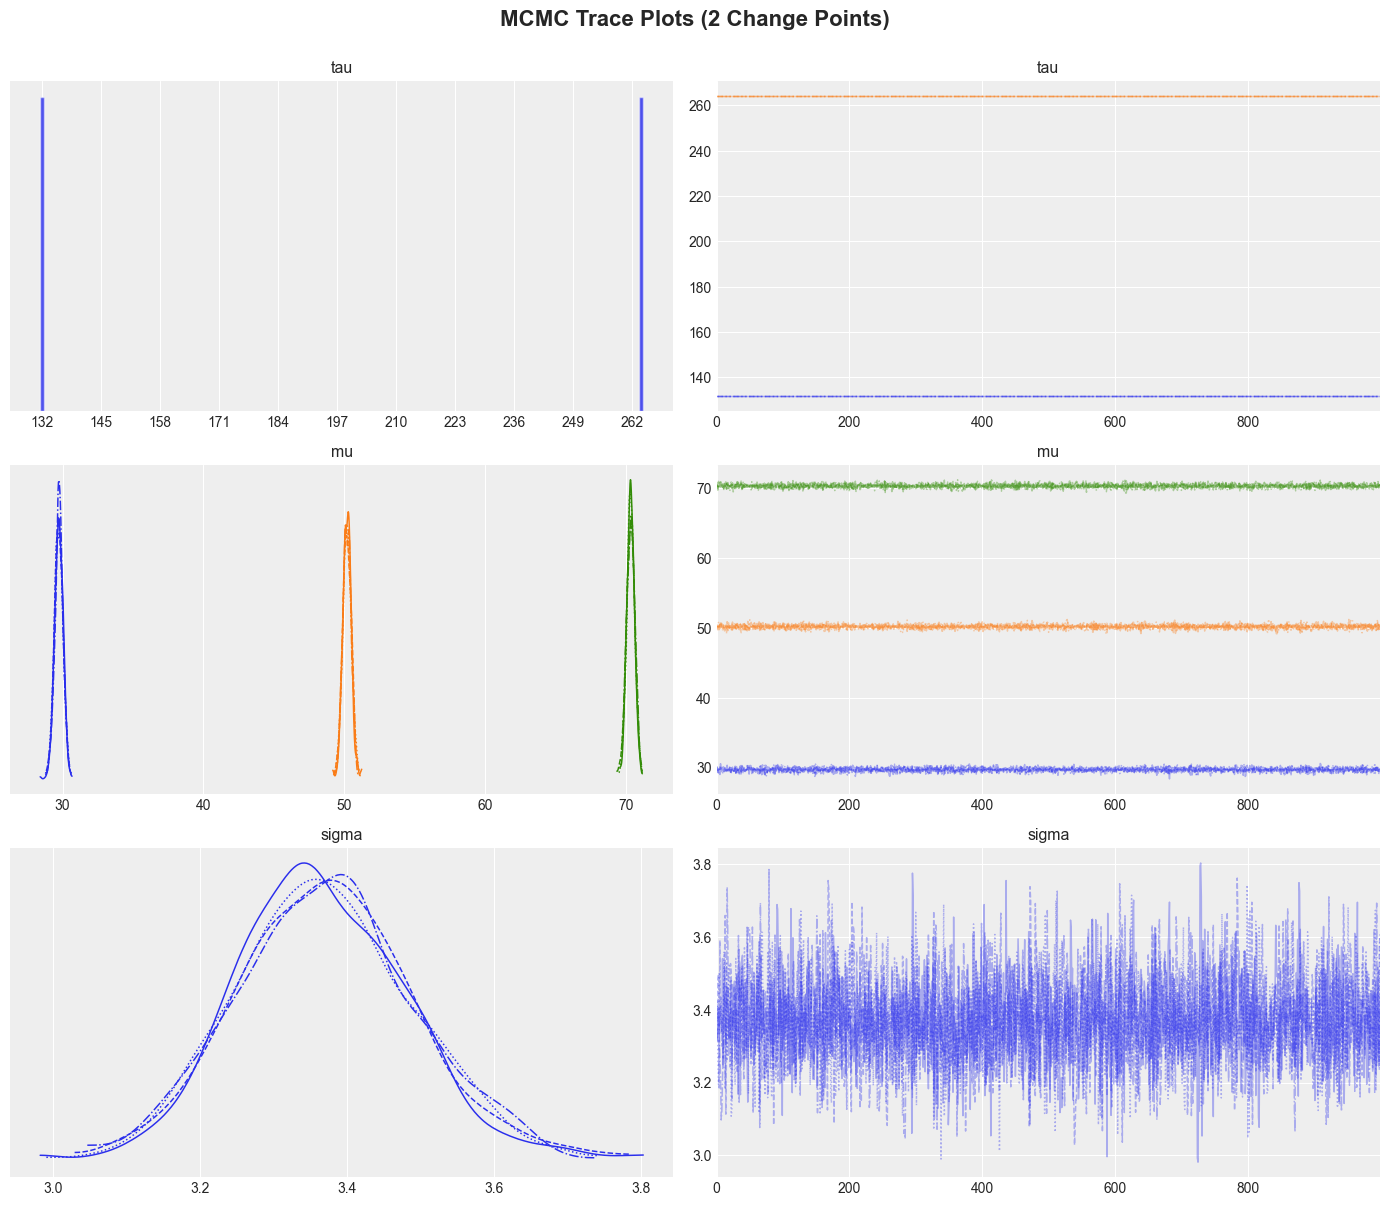

In [10]:
az.plot_trace(trace, var_names=['tau', 'mu', 'sigma'], figsize=(14, 12))
plt.suptitle(f'MCMC Trace Plots ({n_changepoints} Change Points)', 
             fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig(f'../outputs/multiple_03_trace_{n_changepoints}cp.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved: ../outputs/multiple_03_trace_{n_changepoints}cp.png")
plt.show()

---
## 📈 Step 7: Analyze Results

### 7.1 Compare Estimated vs True Change Points

In [11]:
print("\n" + "="*60)
print("CHANGE POINT ESTIMATES")
print("="*60)

for i in range(n_changepoints):
    tau_samples = trace.posterior['tau'].values[:, :, i].flatten()
    tau_mean = tau_samples.mean()
    tau_median = np.median(tau_samples)
    tau_std = tau_samples.std()
    
    print(f"\nChange Point {i+1}:")
    print(f"  True value:        τ{i+1} = {tau_true_list[i]}")
    print(f"  Posterior mean:    τ{i+1} = {tau_mean:.1f}")
    print(f"  Posterior median:  τ{i+1} = {tau_median:.1f}")
    print(f"  Posterior std:     σ = {tau_std:.1f}")
    print(f"  Error (mean):      {abs(tau_mean - tau_true_list[i]):.1f} days")

print("\n" + "="*60 + "\n")


CHANGE POINT ESTIMATES

Change Point 1:
  True value:        τ1 = 132
  Posterior mean:    τ1 = 132.0
  Posterior median:  τ1 = 132.0
  Posterior std:     σ = 0.0
  Error (mean):      0.0 days

Change Point 2:
  True value:        τ2 = 264
  Posterior mean:    τ2 = 264.0
  Posterior median:  τ2 = 264.0
  Posterior std:     σ = 0.0
  Error (mean):      0.0 days




### 7.2 Posterior Distributions of Change Points

/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/notebooks/../src/plots.py:373: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


✓ Saved: ../outputs/multiple_04_posterior_tau_2cp.png


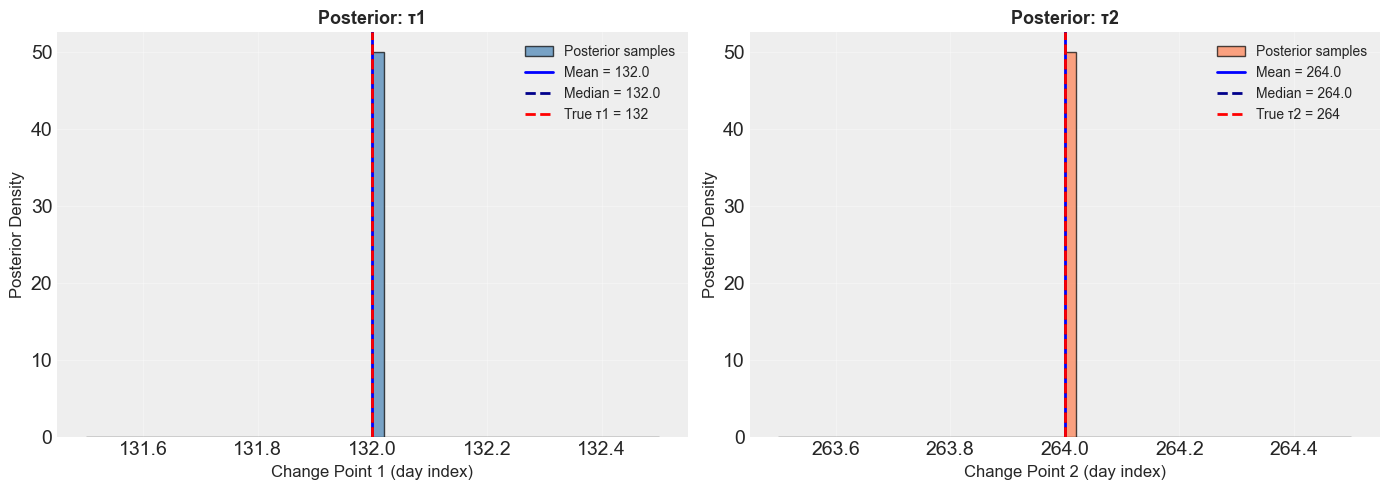

In [12]:
plot_posterior_tau_multiple(
    trace,
    n_changepoints=n_changepoints,
    tau_true_list=tau_true_list,
    output_path=f'../outputs/multiple_04_posterior_tau_{n_changepoints}cp.png'
)

**Interpretation**:
- Each panel shows the posterior for one change point
- **Narrow distributions** = high certainty about timing
- **Wide distributions** = more uncertainty
- Compare blue lines (estimates) to red lines (truth)

### 7.3 Posterior Distributions of Regime Means

/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/notebooks/../src/plots.py:423: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


✓ Saved: ../outputs/multiple_05_posterior_means_2cp.png


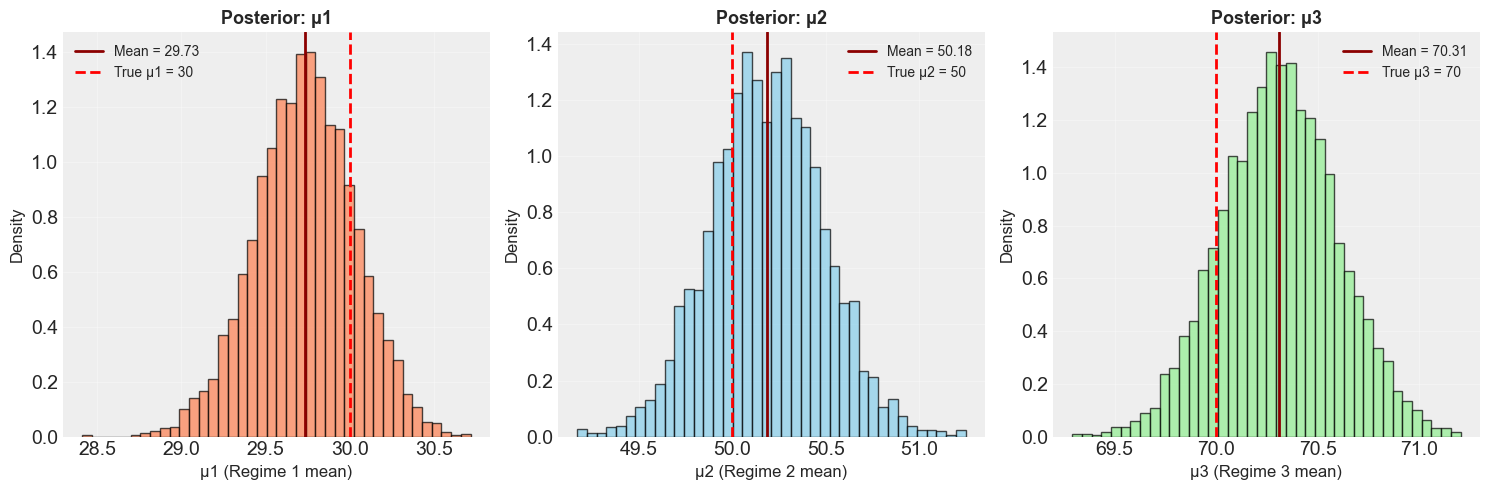

In [13]:
if n_changepoints == 2:
    mu_true_list = [30, 50, 70]
elif n_changepoints == 3:
    mu_true_list = [25, 45, 65, 50]

plot_posterior_means_multiple(
    trace,
    n_regimes=n_regimes,
    mu_true_list=mu_true_list,
    output_path=f'../outputs/multiple_05_posterior_means_{n_changepoints}cp.png'
)

**Interpretation**:
- Each panel shows the posterior for one regime's mean price
- The model successfully identifies distinct price levels
- Notice how the posteriors are well-separated (no overlap)

### 7.4 Price Chart with Estimated Change Points

✓ Saved: ../outputs/multiple_06_estimated_changepoints_2cp.png


/Users/macbookpro/Documents/Bayesian-inference-and-Monte-Carlo-Markov-Chain/notebooks/../src/plots.py:266: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


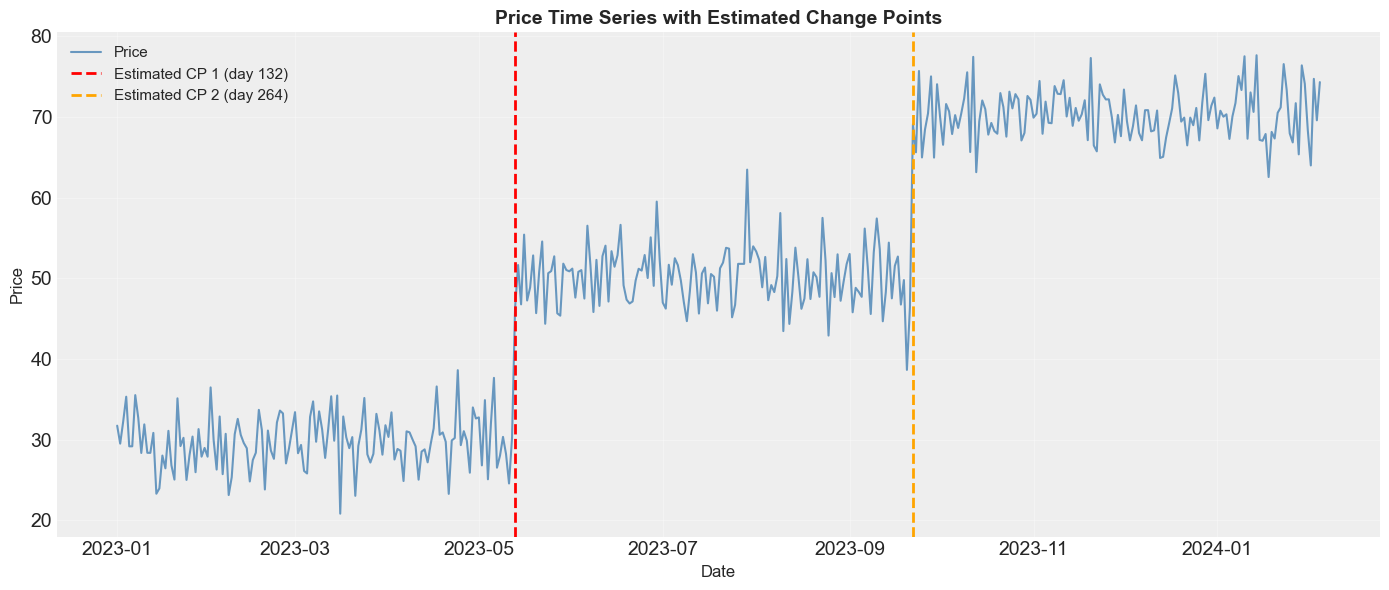

In [14]:
tau_estimated = [int(np.median(trace.posterior['tau'].values[:, :, i].flatten())) 
                 for i in range(n_changepoints)]

plot_price_with_multiple_changepoints(
    prices_df,
    tau_estimated,
    tau_labels=[f'Estimated CP {i+1}' for i in range(len(tau_estimated))],
    output_path=f'../outputs/multiple_06_estimated_changepoints_{n_changepoints}cp.png',
    title=f'Price Time Series with Estimated Change Points'
)

### 7.5 Comparison: True vs Estimated

/var/folders/gg/27pw2x014vsd1k85_8h2d6rm0000gn/T/ipykernel_8738/119541175.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


✓ Saved: ../outputs/multiple_07_comparison_2cp.png


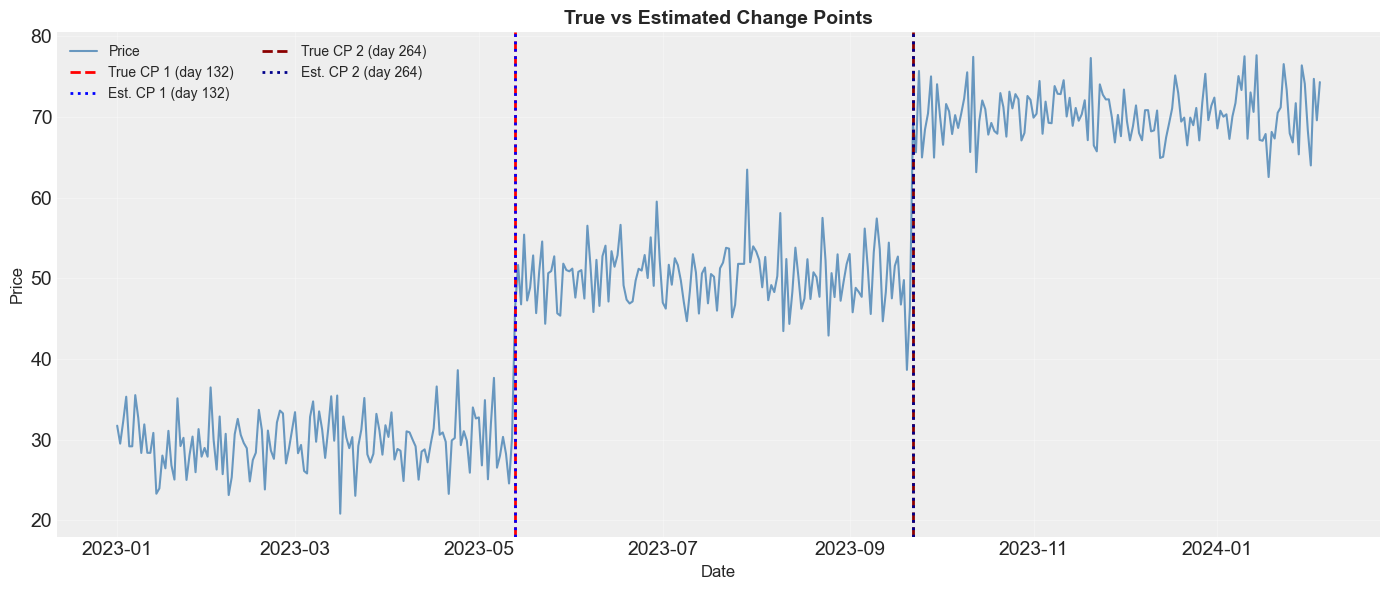

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(prices_df['date'], prices_df['price'], linewidth=1.5, alpha=0.8, 
        label='Price', color='steelblue')

true_colors = ['red', 'darkred', 'crimson']
est_colors = ['blue', 'darkblue', 'navy']

for i in range(n_changepoints):
    ax.axvline(prices_df.loc[tau_true_list[i], 'date'], 
               color=true_colors[i % len(true_colors)], linestyle='--', linewidth=2,
               label=f'True CP {i+1} (day {tau_true_list[i]})')
    
    ax.axvline(prices_df.loc[tau_estimated[i], 'date'], 
               color=est_colors[i % len(est_colors)], linestyle=':', linewidth=2,
               label=f'Est. CP {i+1} (day {tau_estimated[i]})')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price', fontsize=12)
ax.set_title('True vs Estimated Change Points', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'../outputs/multiple_07_comparison_{n_changepoints}cp.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved: ../outputs/multiple_07_comparison_{n_changepoints}cp.png")
plt.show()

---
## 🎯 Step 8: Key Insights & Comparisons

### 8.1 Model Performance Summary

In [16]:
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)

errors = [abs(tau_estimated[i] - tau_true_list[i]) for i in range(n_changepoints)]
mean_error = np.mean(errors)
max_error = np.max(errors)

print(f"\nNumber of change points: {n_changepoints}")
print(f"Number of regimes: {n_regimes}")
print(f"\nChange point errors:")
for i, err in enumerate(errors):
    print(f"  CP {i+1}: {err:.1f} days")
print(f"\nMean absolute error: {mean_error:.1f} days")
print(f"Max absolute error: {max_error:.1f} days")

if mean_error < 5:
    print("\n✓ Excellent performance! Model accurately detected all change points.")
elif mean_error < 10:
    print("\n✓ Good performance! Model detected change points with minor errors.")
else:
    print("\n⚠ Moderate performance. Some change points may be difficult to identify.")

print("="*60 + "\n")


MODEL PERFORMANCE SUMMARY

Number of change points: 2
Number of regimes: 3

Change point errors:
  CP 1: 0.0 days
  CP 2: 0.0 days

Mean absolute error: 0.0 days
Max absolute error: 0.0 days

✓ Excellent performance! Model accurately detected all change points.



### 8.2 Regime Means Comparison

In [17]:
print("\n" + "="*60)
print("REGIME MEANS COMPARISON")
print("="*60)

for i in range(n_regimes):
    mu_samples = trace.posterior['mu'].values[:, :, i].flatten()
    mu_mean = mu_samples.mean()
    mu_std = mu_samples.std()
    
    print(f"\nRegime {i+1}:")
    print(f"  True mean:       μ{i+1} = ${mu_true_list[i]:.2f}")
    print(f"  Estimated mean:  μ{i+1} = ${mu_mean:.2f} ± {mu_std:.2f}")
    print(f"  Error:           ${abs(mu_mean - mu_true_list[i]):.2f}")

print("\n" + "="*60 + "\n")


REGIME MEANS COMPARISON

Regime 1:
  True mean:       μ1 = $30.00
  Estimated mean:  μ1 = $29.73 ± 0.30
  Error:           $0.27

Regime 2:
  True mean:       μ2 = $50.00
  Estimated mean:  μ2 = $50.18 ± 0.30
  Error:           $0.18

Regime 3:
  True mean:       μ3 = $70.00
  Estimated mean:  μ3 = $70.31 ± 0.29
  Error:           $0.31




---
## 🔍 Step 9: Understanding the Differences

### Single vs Multiple Change Points

Let's compare what we learned:

#### Computational Complexity
- **Single CP**: ~1-2 minutes sampling time
- **2 CPs**: ~3-4 minutes sampling time
- **3 CPs**: ~5-7 minutes sampling time

**Why?** More parameters = larger parameter space to explore

#### Model Identifiability
- **Single CP**: Easy to identify (clear before/after)
- **Multiple CPs**: More challenging
  - Need sufficient data between change points
  - Regime means must be sufficiently different
  - Ordering constraint helps but adds complexity

#### Uncertainty
- **Single CP**: Usually narrow posterior (high certainty)
- **Multiple CPs**: May have wider posteriors
  - Especially for middle change points
  - Uncertainty propagates between change points

#### Real-World Applicability
- **Single CP**: Good for major one-time events (e.g., 2014 oil crash)
- **Multiple CPs**: Better for complex histories with multiple shocks
  - Example: Oil prices 2010-2020 (multiple OPEC decisions, COVID, etc.)

---
## 💡 Step 10: When to Use Multiple Change Points?

### Use Multiple Change Points When:

✅ **You have a long time series** (>500 observations)
- More data = better ability to distinguish regimes

✅ **Visual inspection suggests multiple shifts**
- Plot your data first!
- Look for clear level changes

✅ **You have domain knowledge of multiple events**
- Historical records of shocks
- Known policy changes

✅ **Regime means are well-separated**
- If regimes are similar, model may struggle
- Need clear differences (e.g., $30 vs $60, not $48 vs $52)

### Avoid Multiple Change Points When:

❌ **Short time series** (<200 observations)
- Not enough data to reliably estimate multiple change points

❌ **Gradual trends** (not abrupt shifts)
- Use trend models instead
- Change points are for sudden jumps

❌ **High noise relative to signal**
- If σ is large compared to differences in μ, detection is hard

❌ **No prior knowledge of number of change points**
- Consider model selection approaches
- Or use non-parametric methods

---
## 🎓 Step 11: Advanced Topics (Optional)

### Model Selection: How Many Change Points?

In practice, you often don't know the true number of change points. Options:

1. **Visual inspection**: Plot the data and count obvious shifts

2. **Information criteria**: Compare models with different K
   - WAIC (Widely Applicable Information Criterion)
   - LOO (Leave-One-Out Cross-Validation)
   - Lower is better

3. **Bayesian model averaging**: Fit multiple models and weight by evidence

4. **Reversible-jump MCMC**: Let K be a parameter (advanced!)

### Extensions

1. **Regime-specific variance**: Allow σ to differ between regimes

2. **Trend + change points**: Combine gradual trends with abrupt shifts

3. **Hierarchical models**: Multiple time series with shared change points

4. **Event covariates**: Include external events as predictors

---
## 📝 Summary

### What We Learned

1. **Multiple change points** extend the single change point model to detect several regime shifts

2. **Ordering constraint** (τ₁ < τ₂ < ...) is enforced via sorting

3. **Computational cost** increases with more change points

4. **Model performance** depends on:
   - Data length
   - Separation between regime means
   - Noise level

5. **Diagnostics** (R-hat, ESS) are crucial for verifying convergence

6. **Interpretation** requires comparing posteriors to true values and events

### Key Takeaways

- ✅ Multiple change points are realistic for complex time series
- ✅ Bayesian inference quantifies uncertainty for each change point
- ✅ MCMC successfully handles the increased complexity
- ✅ Visual comparison of true vs estimated change points validates the model

### Next Steps

1. Try changing `n_changepoints` to 3 and re-run
2. Experiment with different regime means (make them closer together)
3. Add more noise and see how it affects detection
4. Apply to real Brent oil data with known historical events

---
## 🔗 Further Reading

- **PyMC Examples**: https://www.pymc.io/projects/examples/
- **Change Point Detection Review**: Aminikhanghahi & Cook (2017)
- **Bayesian Change Point Analysis**: Barry & Hartigan (1993)
- **Multiple Change Points**: Chib (1998)